In [ ]:
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Styling
import matplotlib.style as style

style.use("fivethirtyeight")

# Statistics
from scipy.stats import zscore, norm

# Sklearn - Preprocessing
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
 )
from sklearn.impute import SimpleImputer

# Create preprocessing pipeline with ColumnTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Sklearn - Model Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    KFold,
    cross_val_score,
 )
from sklearn.model_selection import RandomizedSearchCV

# Sklearn - Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from random import randint
from sklearn.ensemble import RandomForestRegressor

# Sklearn - Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
 )

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Imbalanced Learning
# from imblearn.over_sampling import SMOTE


# Set display options for better readability
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
np.random.seed(42)

sns.set_style("whitegrid")
# Define the data file path
DATA_PATH = "student-data-25s3.csv"
TARGET = "G3"  # Define the target variable

# 1. Data Preparation

Load and inspect the dataset for quality issues.

In [106]:
# Load the data
df = pd.read_csv(DATA_PATH)

# Basic info
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (650, 25)
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'traveltime', 'studytime', 'failures', 'activities', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'health', 'absences', 'G1', 'G2', 'G3']


,school,sex,age,address,famsize,Medu,Fedu,Mjob,Fjob,reason,traveltime,studytime,failures,activities,higher,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,4,4,at_home,teacher,course,2,2,0,no,yes,no,no,4,3,4,3,4,0,11,11
1,GP,F,17,U,GT3,1,1,at_home,other,course,1,2,0,no,yes,yes,no,5,3,3,3,2,9,11,11
2,GP,F,15,U,LE3,1,1,at_home,other,other,1,2,0,no,yes,yes,no,4,3,2,3,6,12,13,12
3,GP,F,15,U,GT3,4,2,health,services,home,1,3,0,yes,yes,yes,yes,3,2,2,5,0,14,14,14
4,GP,F,16,U,GT3,3,3,other,other,home,1,2,0,no,yes,no,no,4,3,2,5,0,11,13,13


# 2. Data Quality Checks

Identify issues in the data including duplicates, null values, unique values, domain violations, and outliers.

## Check Duplicates

Find and optionally remove duplicate rows.

In [107]:
# Count duplicate rows
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

# View duplicate rows (if any)
if dup_count > 0:
    display(df[df.duplicated(keep=False)])

# Remove duplicates (uncomment to use)
# df = df.drop_duplicates()
# print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows: 6


,school,sex,age,address,famsize,Medu,Fedu,Mjob,Fjob,reason,traveltime,studytime,failures,activities,higher,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3
58,GP,M,15,U,LE3,1,2,other,at_home,home,1,2,0,yes,yes,yes,no,4,3,2,5,0,14,13,14
59,GP,M,15,U,LE3,1,2,other,at_home,home,1,2,0,yes,yes,yes,no,4,3,2,5,0,14,13,14
60,GP,M,15,U,LE3,1,2,other,at_home,home,1,2,0,yes,yes,yes,no,4,3,2,5,0,14,13,14
299,GP,F,20,R,GT3,2,1,other,other,course,2,2,0,yes,no,yes,yes,1,2,3,2,8,10,12,12
300,GP,F,20,R,GT3,2,1,other,other,course,2,2,0,yes,no,yes,yes,1,2,3,2,8,10,12,12
301,GP,F,20,R,GT3,2,1,other,other,course,2,2,0,yes,no,yes,yes,1,2,3,2,8,10,12,12
448,MS,F,16,R,GT3,4,4,teacher,teacher,course,2,3,0,yes,yes,yes,yes,4,2,2,4,6,16,16,17
468,MS,F,16,R,GT3,4,4,teacher,teacher,course,2,3,0,yes,yes,yes,yes,4,2,2,4,6,16,16,17
473,MS,F,16,R,GT3,4,4,teacher,teacher,course,2,3,0,yes,yes,yes,yes,4,2,2,4,6,16,16,17


## Check Null Values

Count and display missing values per column.

In [108]:
# Count null values per column
null_counts = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df) * 100).round(2)

null_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_percent': null_percent
})
print(null_summary[null_summary['null_count'] > 0])

# Total nulls
print(f"\nTotal null values: {df.isnull().sum().sum()}")

           null_count  null_percent
school              1          0.15
sex                 1          0.15
Mjob                1          0.15
Fjob                1          0.15
studytime           3          0.46
G1                  1          0.15

Total null values: 8


In [109]:
# view rows with nulls
display(df[df.isnull().any(axis=1)])

,school,sex,age,address,famsize,Medu,Fedu,Mjob,Fjob,reason,traveltime,studytime,failures,activities,higher,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3
119,GP,M,15,U,GT3,3,4,other,other,reputation,1,NaN,0,no,yes,yes,no,3,4,3,4,2,14,13,14
120,GP,F,15,U,GT3,1,2,at_home,services,course,1,NaN,0,no,yes,yes,no,3,2,3,1,0,14,14,14
208,GP,M,16,U,GT3,2,3,NaN,other,home,2,1,0,no,yes,yes,no,5,3,3,3,0,NaN,12,12
209,GP,F,17,U,LE3,2,4,other,NaN,course,1,2,0,yes,yes,yes,yes,4,3,2,5,8,4,15,16
324,GP,M,18,U,GT3,1,2,at_home,other,home,2,NaN,0,no,no,yes,no,3,4,4,4,10,10,10,11
649,NaN,NaN,170,0,0,4,4,0,0,0,4,11,3,0,0,0,0,5,5,5,5,32,132,19,19


## Check Unique Values

Display unique values and their counts for each column.

In [110]:
# Show unique values for each column
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"{col}: {len(unique_vals)} unique values")
    # Show unique values and their counts
    
    for val in unique_vals:
        count = (df[col] == val).sum()
        print(f"  {val}: {count}")
    
    print("-----------")
    

school: 3 unique values
  GP: 423
  MS: 226
  nan: 0
-----------
sex: 3 unique values
  F: 384
  M: 265
  nan: 0
-----------
age: 14 unique values
  18: 138
  17: 178
  15: 111
  16: 173
  19: 32
  22: 1
  20: 8
  21: 2
  105: 1
  106: 1
  115: 1
  2O: 1
  1O: 1
  170: 2
-----------
address: 3 unique values
  U: 449
  R: 200
  0: 1
-----------
famsize: 3 unique values
  GT3: 456
  LE3: 193
  0: 1
-----------
Medu: 5 unique values
  4: 174
  1: 145
  3: 139
  2: 186
  0: 6
-----------
Fedu: 5 unique values
  4: 130
  1: 175
  2: 209
  3: 129
  0: 7
-----------
Mjob: 10 unique values
  at_home: 127
  health: 46
  other: 262
  services: 130
  teacher: 73
  service: 3
  nan: 0
  at home: 4
  home: 3
  0: 1
-----------
Fjob: 8 unique values
  teacher: 37
  other: 360
  services: 179
  health: 23
  at_home: 44
  nan: 0
  others: 5
  0: 1
-----------
reason: 5 unique values
  course: 286
  other: 71
  home: 150
  reputation: 142
  0: 1
-----------
traveltime: 4 unique values
  2: 216
  1: 364

In [111]:
# Function to check domain constraint violations
def check_domain_violations(df, col, valid_mask):
    """
    Check values outside domain constraints.

    Args:
        df: DataFrame
        col: Column name to check
        valid_mask: Boolean mask where True = valid values

    Returns:
        Count of violations and displays invalid rows
    """
    violations = df[~valid_mask]
    print(f"{col}: {len(violations)} values outside domain constraints")
    if len(violations) > 0:
        display(violations[[col]])
    
    print("\n-----------\n")
    # return len(violations)

## Check Domain Violations

Verify values fall within expected constraints.

In [112]:
# Example: Check if 'G3' is between 0 and 100
check_domain_violations(df, "G3", (df["G3"] >= 0) & (df["G3"] <= 100))

G3: 0 values outside domain constraints

-----------



In [113]:
# Check for leading/trailing whitespace in string columns
string_cols = df.select_dtypes(include="object").columns
isExtraWhitespace = False

for col in string_cols:
    whitespace_count = (df[col] != df[col].str.strip()).sum()
    if whitespace_count > 0:
        isExtraWhitespace = True
        print(f"{col}: {whitespace_count} entries with extra whitespace")
        print("-----------")
if not isExtraWhitespace:
    print("No leading/trailing whitespace issues detected in string columns.")


school: 1 entries with extra whitespace
-----------
sex: 1 entries with extra whitespace
-----------
Mjob: 1 entries with extra whitespace
-----------
Fjob: 1 entries with extra whitespace
-----------
studytime: 3 entries with extra whitespace
-----------
G1: 1 entries with extra whitespace
-----------


In [114]:
# Check for inconsistent casing in string columns
isInconsistentCasing = False
for col in string_cols:
    
    unique_vals = df[col].dropna().unique()
    lower_unique = df[col].str.lower().dropna().unique()

    if len(unique_vals) != len(lower_unique):
        print(f"{col}: Possible casing inconsistencies")
        print(f"  Original unique: {list(unique_vals)}")
        print(f"  Lowercased unique: {list(lower_unique)}")
        print("-----------")
        isInconsistentCasing = True

if not isInconsistentCasing:
    print("No casing issues detected in string columns.")

No casing issues detected in string columns.


## Check Outliers

Identify outliers using box plots and IQR method.

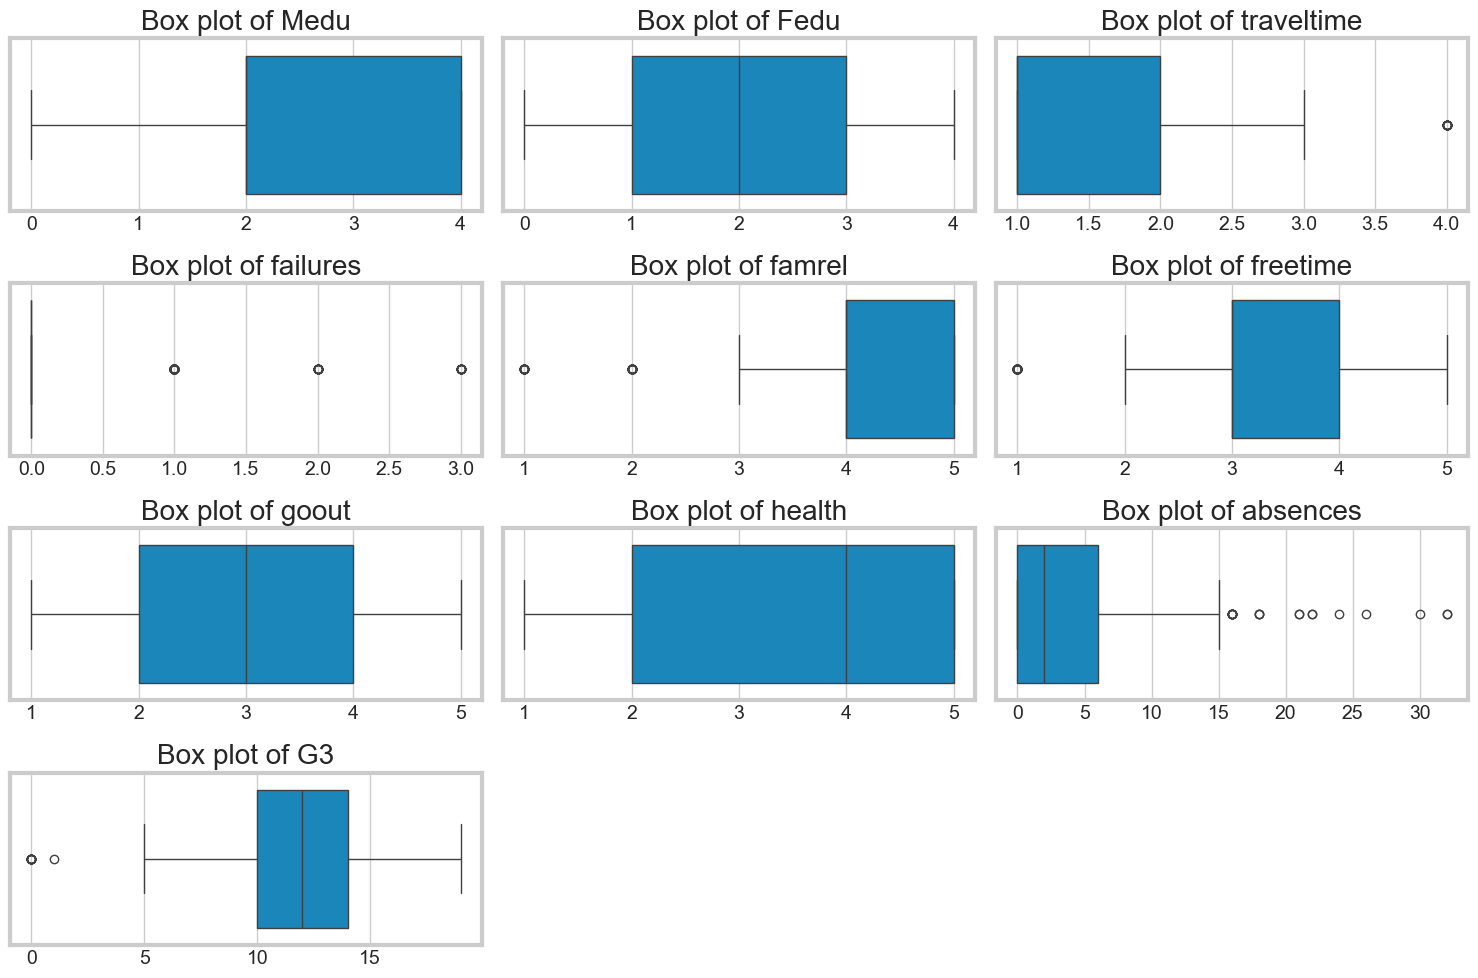

In [115]:
# display all box plots
_, subs = plt.subplots(math.ceil(len(df.select_dtypes(include=np.number).columns) / 3), 3, figsize=(15, 10))

for i, col in enumerate(df.select_dtypes(include=np.number).columns):
    sns.boxplot(x=df[col], ax=subs[i // 3, i % 3])
    subs[i // 3, i % 3].set_title(f'Box plot of {col}')
    subs[i // 3, i % 3].set_xlabel("")

# Hide empty subplots
for j in range(len(df.select_dtypes(include=np.number).columns), len(subs.flatten())):
    subs[j // 3, j % 3].axis("off")

plt.tight_layout()
plt.show()

In [116]:
# display number of outliers per numerical column based on 1.5*IQR rule
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")



Medu: 0 outliers
Fedu: 0 outliers
traveltime: 17 outliers
failures: 101 outliers
famrel: 51 outliers
freetime: 44 outliers
goout: 0 outliers
health: 0 outliers
absences: 22 outliers
G3: 16 outliers


# 3. Data Cleaning

Remove duplicates, fix domain violations, standardize text, and handle outliers.

In [117]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)
df.shape

(644, 25)

In [118]:
# function to remove rows with domain constraint violations
def remove_domain_violations(df, col, valid_mask):
    """
    Remove rows with values outside domain constraints.

    Args:
        df: DataFrame
        col: Column name to check
        valid_mask: Boolean mask where True = valid values

    Returns:
        DataFrame with invalid rows removed
    """
    invalid_mask = ~valid_mask
    invalid_indices = df[invalid_mask].index.tolist()
    print(f"Removing {len(invalid_indices)} rows with invalid {col} values")
    df = df[valid_mask]
    print(f"Shape after removing domain violations: {df.shape}\n")
    # return df

In [119]:
# Remove domain validation
# df = remove_domain_violations(df, "G3", (df["G3"] >= 0) & (df["G3"] <= 5))

In [120]:
# Trim whitespace and standardize casing in string columns
string_cols = df.select_dtypes(include='object').columns

for col in string_cols:
    df[col] = df[col].str.strip().str.lower()

print("Trimmed whitespace and converted to lowercase for string columns")
df[string_cols].head()

Trimmed whitespace and converted to lowercase for string columns


,school,sex,age,address,famsize,Mjob,Fjob,reason,studytime,activities,higher,internet,romantic,G1,G2
0,gp,f,18,u,gt3,at_home,teacher,course,2,no,yes,no,no,0,11
1,gp,f,17,u,gt3,at_home,other,course,2,no,yes,yes,no,9,11
2,gp,f,15,u,le3,at_home,other,other,2,no,yes,yes,no,12,13
3,gp,f,15,u,gt3,health,services,home,3,yes,yes,yes,yes,14,14
4,gp,f,16,u,gt3,other,other,home,2,no,yes,no,no,11,13


In [121]:
# Convert columns to correct data types
# Example: Convert 'age' to int, 'date' to datetime
# df['date'] = pd.to_datetime(df['date'])
# convert to categorical or ordinal as needed

# Replace values as needed
# df.replace(
#   {}, 
#   inplace=True
# )

# df['age'] = df['age'].astype(int)
# df['Medu'] = pd.Categorical(df['Medu'], ordered=True)
# df['school'] = pd.Categorical(df['school'])

df.dtypes

school        object
sex           object
age           object
address       object
famsize       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
traveltime     int64
studytime     object
failures       int64
activities    object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
health         int64
absences       int64
G1            object
G2            object
G3             int64
dtype: object

In [122]:
# View categories of an ordinal column (with order)
# print(f"Medu categories: {df['Medu'].cat.categories.tolist()}")
# print(f"Medu is ordered: {df['Medu'].cat.ordered}")

In [123]:
# Remove outliers using IQR method
def remove_outliers_iqr(df, col):
    """Remove outliers from a column using 1.5*IQR rule."""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outlier_indices = df[outlier_mask].index.tolist()
    
    if len(outlier_indices) > 0:
        print(f"{col}: Removed {len(outlier_indices)} outliers")
    return df[~outlier_mask]

In [125]:
# df = remove_outliers_iqr(df, "age")

# 4. Data Exploration

Visualize data distributions and patterns.

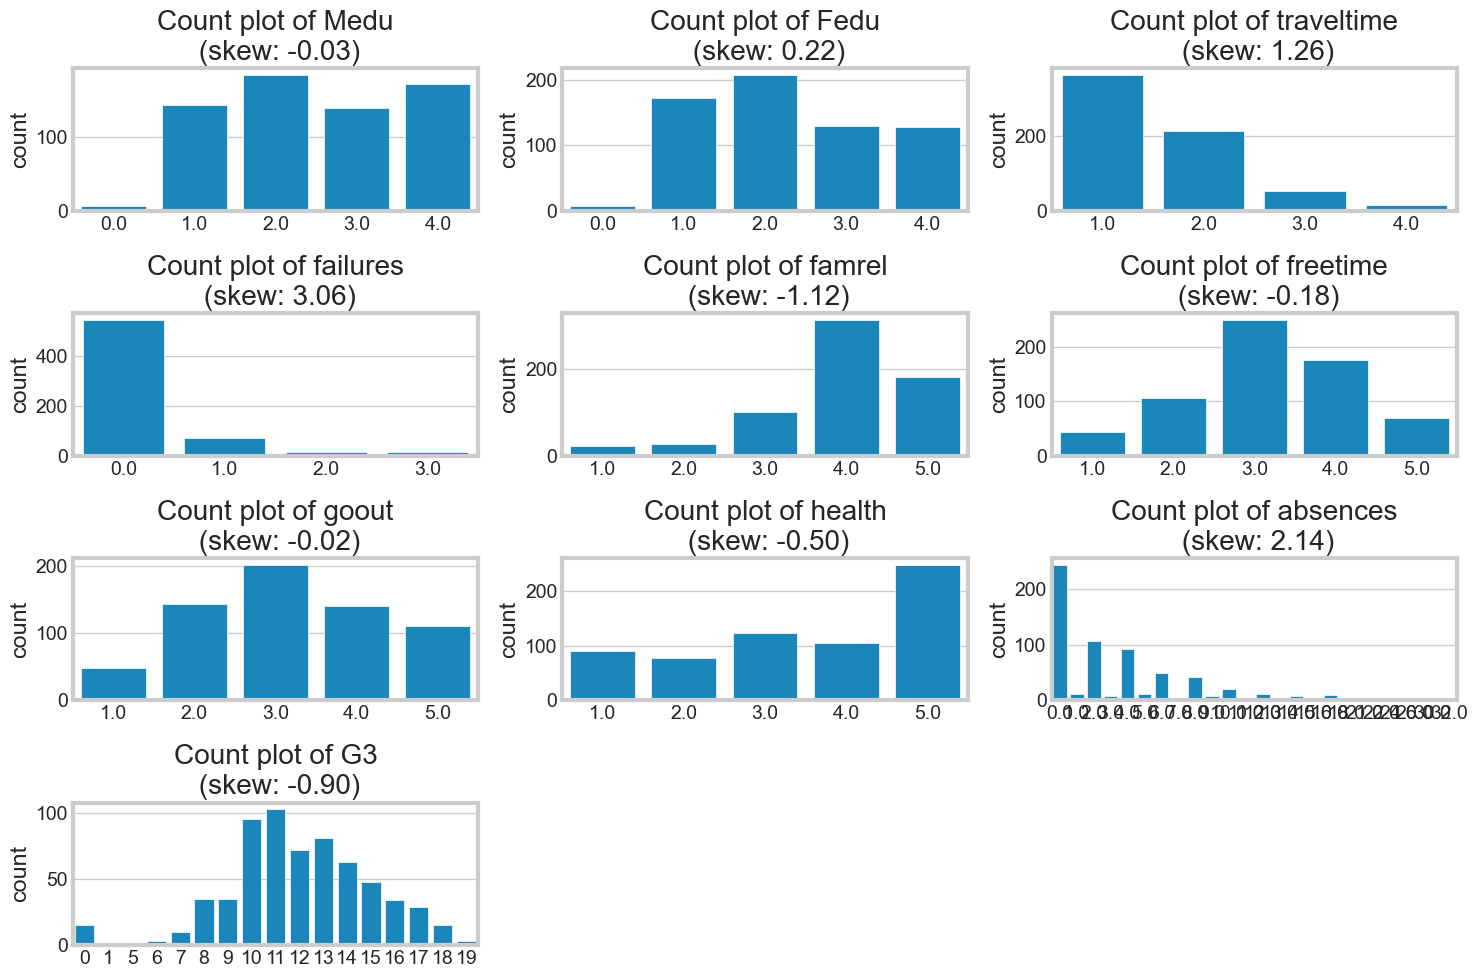

In [126]:
# display all count plots
_, subs = plt.subplots(
    math.ceil(len(df.select_dtypes(include=np.number).columns) / 3), 3, figsize=(15, 10)
)

for i, col in enumerate(df.select_dtypes(include=np.number).columns):
    skew = df[col].skew()
    sns.countplot(x=df[col], ax=subs[i // 3, i % 3])
    subs[i // 3, i % 3].set_title(f"Count plot of {col}\n (skew: {skew:.2f})")
    subs[i // 3, i % 3].set_xlabel("")

# Hide empty subplots
for j in range(len(df.select_dtypes(include=np.number).columns), len(subs.flatten())):
    subs[j // 3, j % 3].axis("off")

plt.tight_layout()
plt.show()

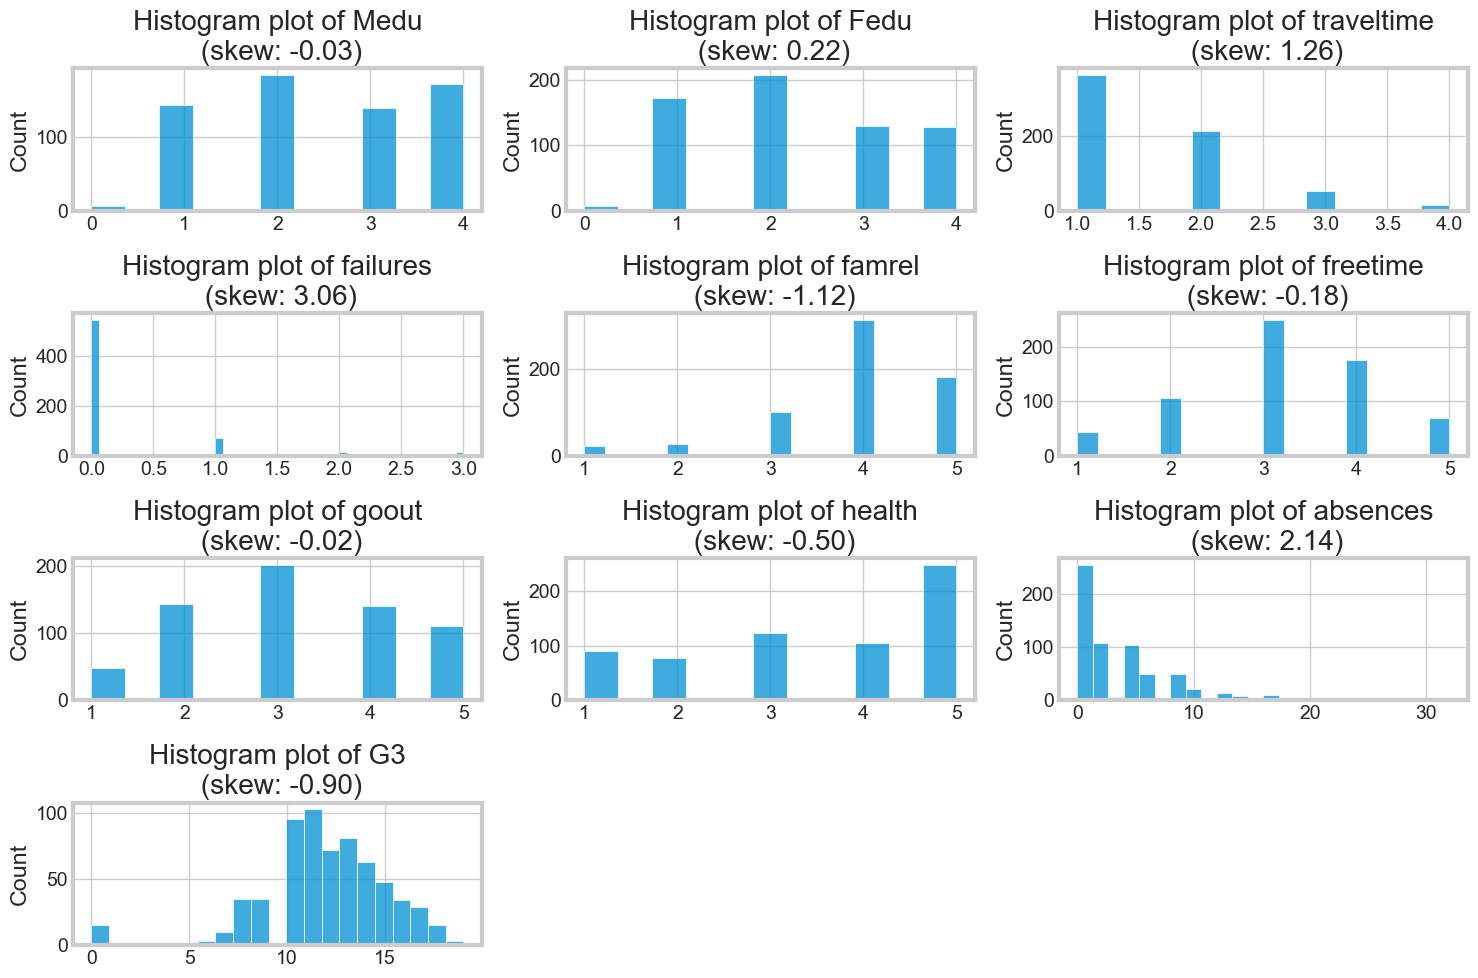

In [127]:
# display all histogram plots
_, subs = plt.subplots(
    math.ceil(len(df.select_dtypes(include=np.number).columns) / 3), 3, figsize=(15, 10)
)

for i, col in enumerate(df.select_dtypes(include=np.number).columns):
    sns.histplot(x=df[col], ax=subs[i // 3, i % 3])
    skew = df[col].skew()
    subs[i // 3, i % 3].set_title(f"Histogram plot of {col}" f"\n (skew: {skew:.2f})")
    subs[i // 3, i % 3].set_xlabel("")

# Hide empty subplots
for j in range(len(df.select_dtypes(include=np.number).columns), len(subs.flatten())):
    subs[j // 3, j % 3].axis("off")

plt.tight_layout()
plt.show()

## Single Column Analysis

Explore individual features using box plots, count plots, histograms, and pie charts.

In [128]:
def plot_boxplot(df, col):
    """Plot boxplot for a given column."""
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Box plot of {col}')
    plt.xlabel(col)
    plt.show()

def plot_countplot(df, col):
    """Plot countplot for a given column."""
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[col])
    plt.title(f'Count plot of {col}')
    plt.xlabel(col)
    plt.show()

def plot_histogram(df, col):
    """Plot histogram for a given column."""
    plt.figure(figsize=(8, 4))
    sns.histplot(x=df[col])
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.show()

def plot_piechart(df, col):
    """Plot pie chart for a given column."""
    plt.figure(figsize=(8, 8))
    df[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
    plt.title(f'Pie chart of {col}')
    # add legend
    plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylabel('')
    plt.show()

## Bivariate Analysis

Analyze relationships between two variables.

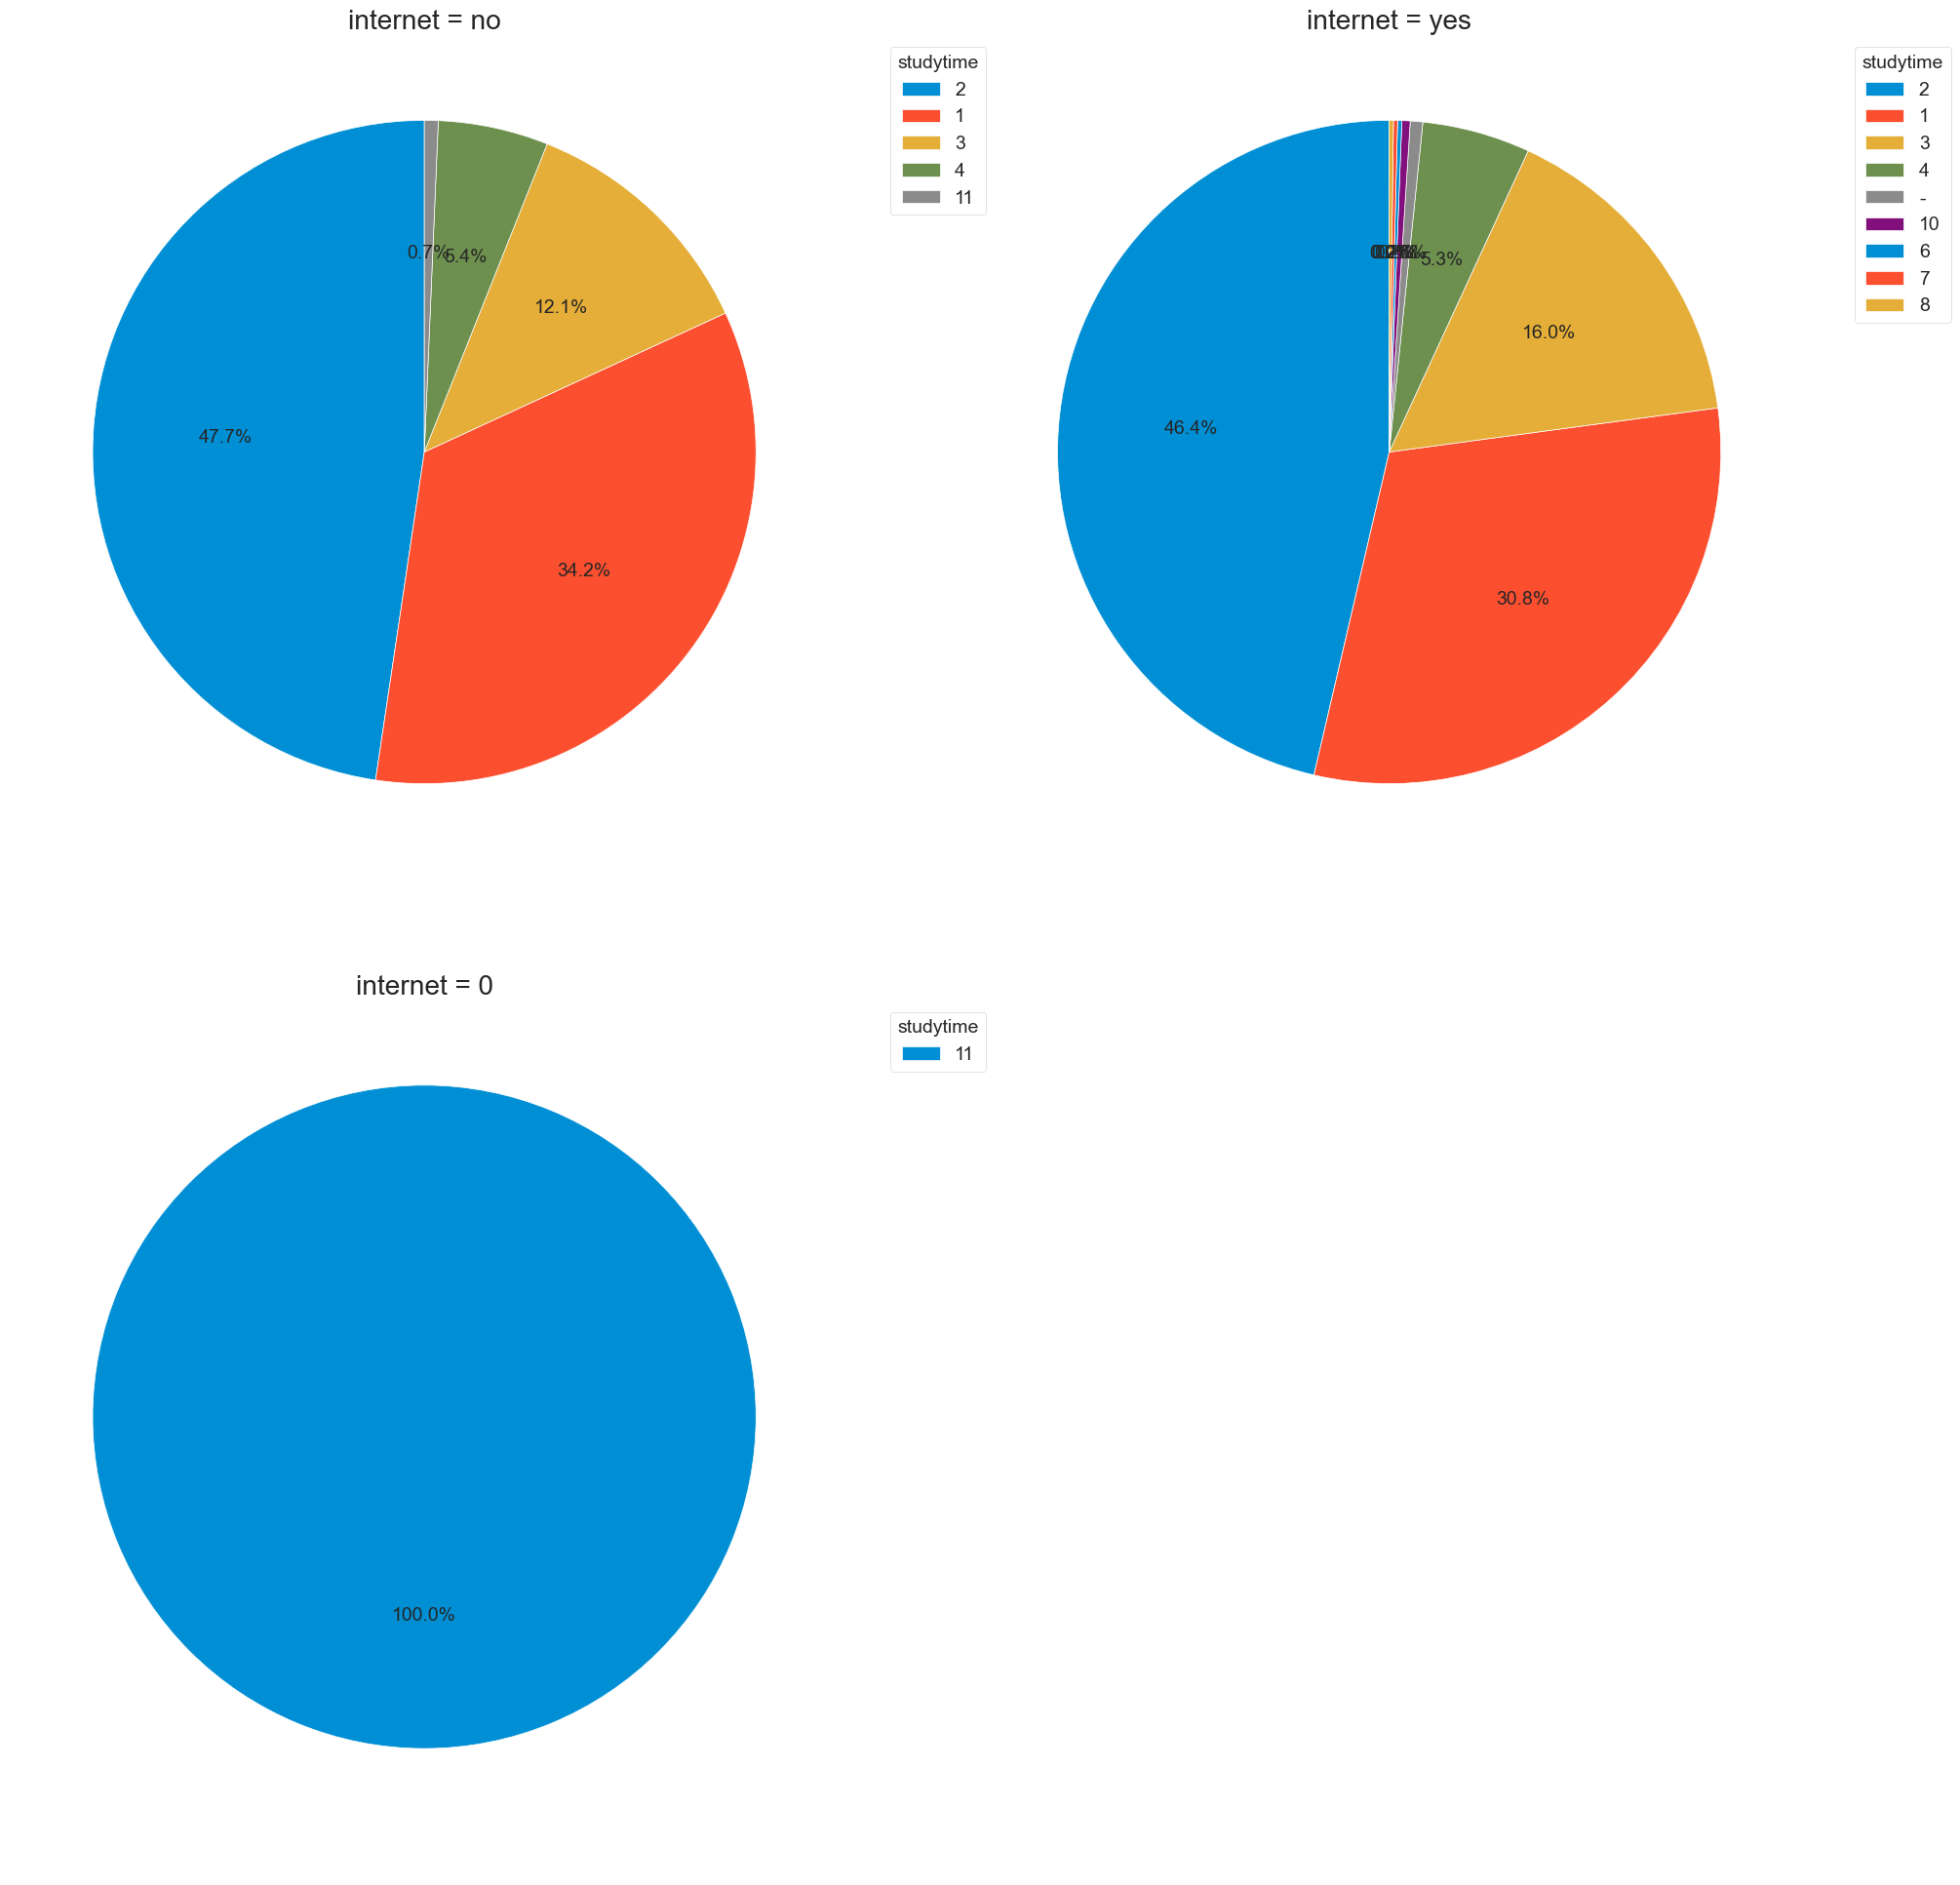

In [129]:
def plot_scatter(df, col1, col2):
    """Plot scatter plot between two columns."""
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df[col1], y=df[col2])
    plt.title(f'Scatter plot of {col1} vs {col2}')
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.show()

def plot_bi_boxplot(df, col1, col2):
    """Plot boxplot of col1 grouped by col2."""
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df[col2], y=df[col1])
    plt.title(f'Box plot of {col1} by {col2}')
    plt.xlabel(col2)
    plt.ylabel(col1)
    plt.show()

def plot_bi_countplot(df, col1, col2):
    """Plot countplot of col1 grouped by col2."""
    plt.figure(figsize=(8, 6))
    sns.countplot(x=df[col1], hue=df[col2])
    plt.title(f'Count plot of {col1} by {col2}')
    plt.xlabel(col1)
    plt.ylabel('Count')
    plt.show()


def plot_bi_piechart(df, col1, col2):
    """Plot pie charts of col1 distribution for each value of col2."""
    groups = df[col2].unique()
    n_groups = len(groups)
    
    fig, axes = plt.subplots(math.ceil(n_groups / 2), 2, figsize=(20, 20))
    
    # Flatten axes array for easier indexing
    if n_groups == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, group in enumerate(groups):
        data = df[df[col2] == group][col1].value_counts()
        axes[i].pie(data, autopct="%1.1f%%", startangle=90)
        # add legend
        axes[i].legend(data.index, title=col1, bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[i].set_title(f"{col2} = {group}")

    # Hide unused subplots
    for j in range(n_groups, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
    
plot_bi_piechart(df, "studytime", "internet")

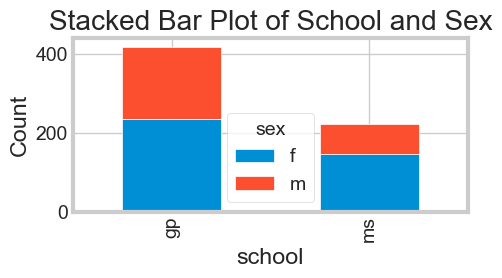

In [130]:
# Stacked bar plot: school vs sex
pd.crosstab(df["school"], df["sex"]).plot(
    kind="bar", stacked=True, figsize=(5, 3)
)
plt.xlabel("school")
plt.ylabel("Count")
plt.title("Stacked Bar Plot of School and Sex")
plt.tight_layout()
plt.show()

## Multi-Column Analysis

Explore correlations and relationships across multiple features.

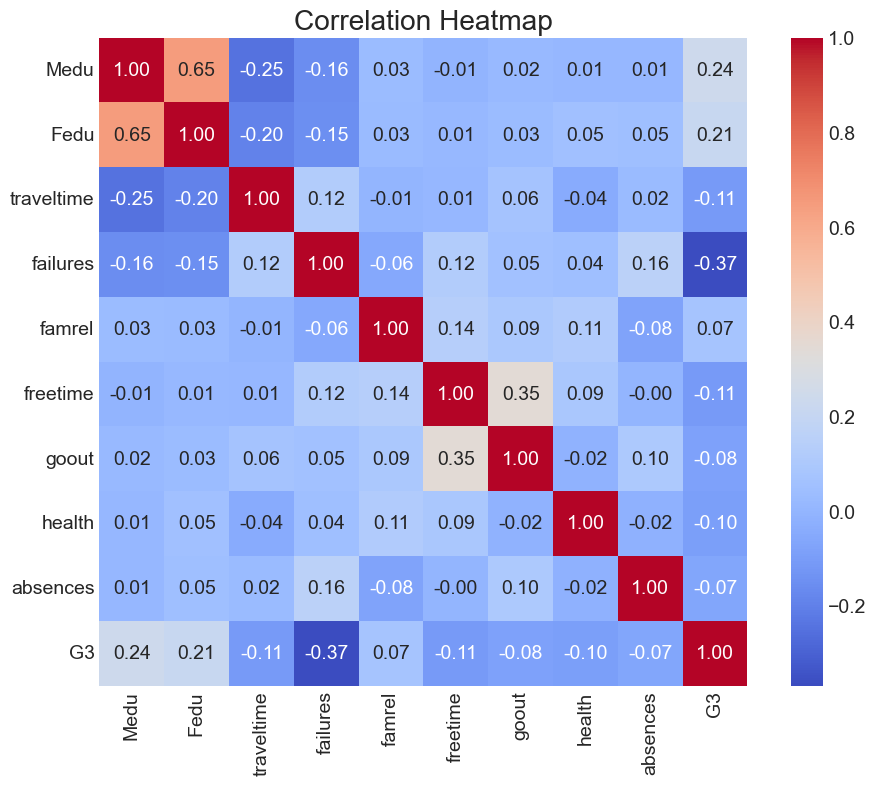

In [131]:
# correlation heatmap
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.show()


In [132]:
# rank feature correlation with target variable
target_corr = corr[TARGET].drop(TARGET).sort_values(ascending=False)
print("Feature correlation with target variable:")
print(target_corr)

Feature correlation with target variable:
Medu          0.238918
Fedu          0.213322
famrel        0.070993
absences     -0.065883
goout        -0.082464
health       -0.096600
traveltime   -0.112491
freetime     -0.112693
failures     -0.369734
Name: G3, dtype: float64


In [133]:
# get correlation feature that are above 0.5 or below -0.5
strong_corr = target_corr[(target_corr >= 0.1) | (target_corr <= -0.1)]
print("\nFeatures with strong correlation (>|0.1|) with target variable:")  
# get columns names
print(strong_corr.index.tolist())


Features with strong correlation (>|0.1|) with target variable:
['Medu', 'Fedu', 'traveltime', 'freetime', 'failures']


In [134]:
# count correlation between 2 feature
corr_value = corr.loc['Medu', 'Fedu']
print(f"\nCorrelation between 'Medu' and 'Fedu': {corr_value}")


Correlation between 'Medu' and 'Fedu': 0.6484388282965976


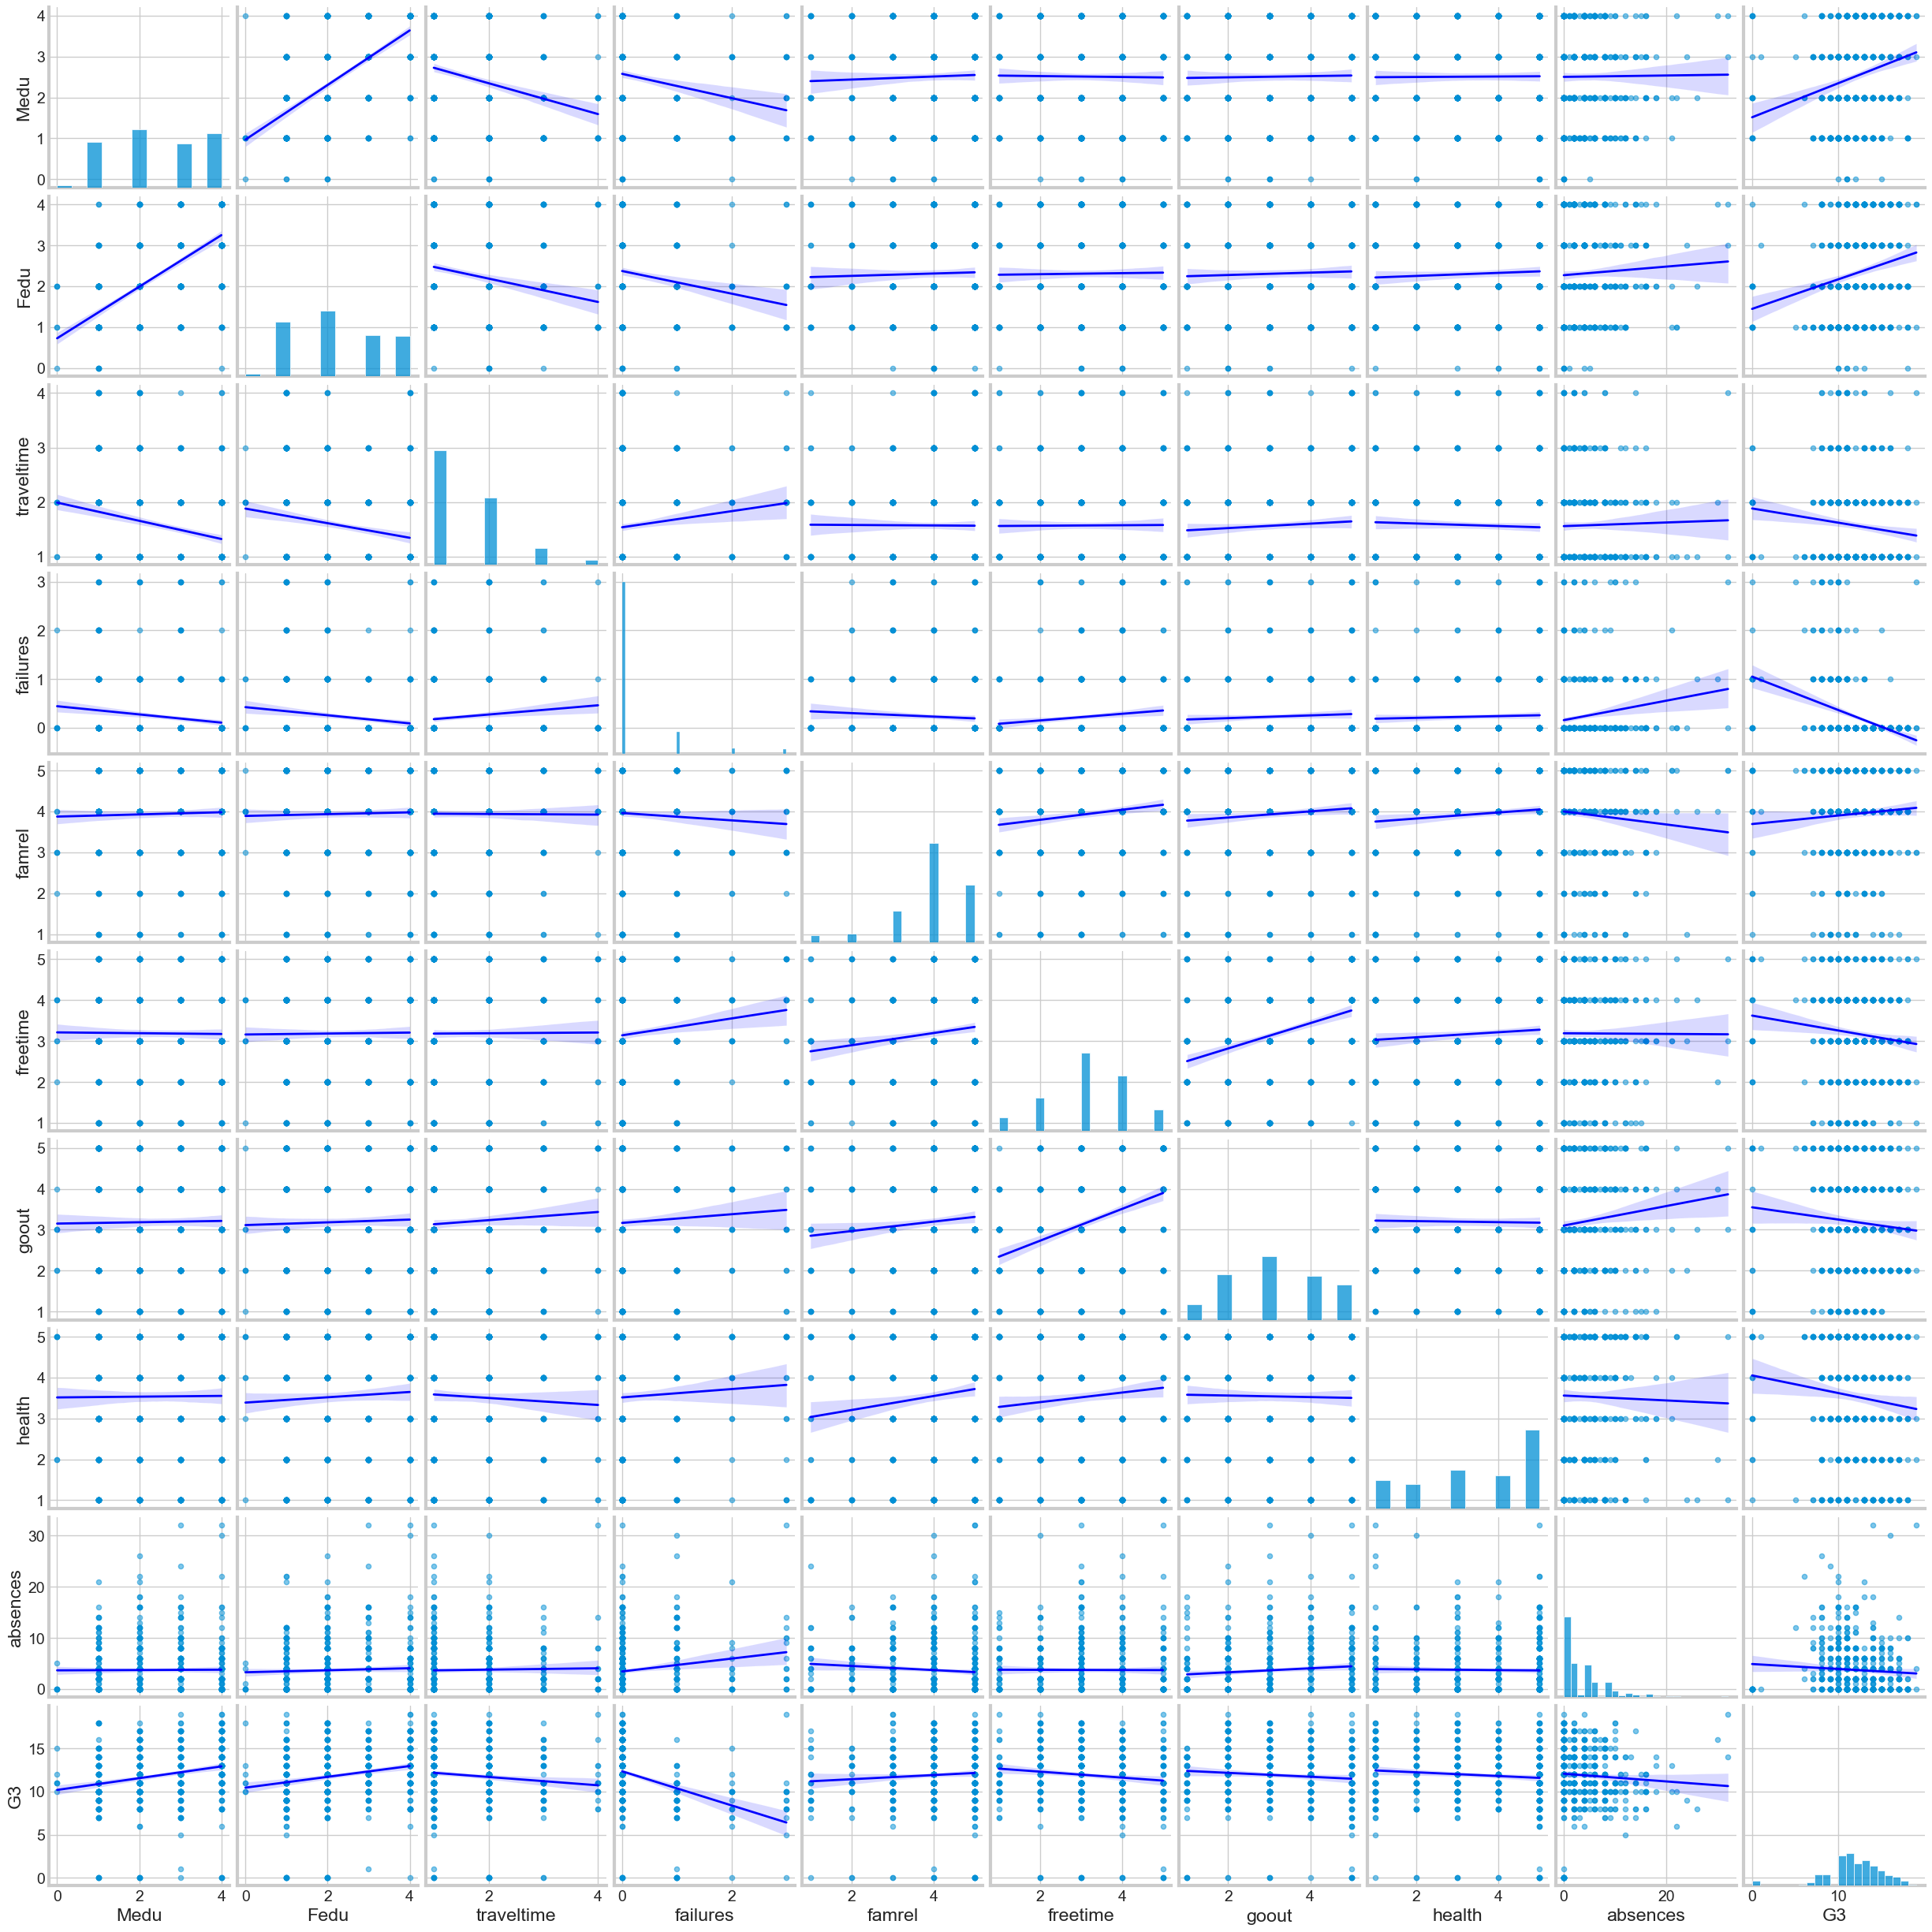

In [135]:
sns.pairplot(
    df.select_dtypes(include=np.number),
    kind="reg",
    plot_kws={
        "scatter_kws": {"alpha": 0.5, "s": 20},
        "line_kws": {"color": "blue", "linewidth": 2},
    },
)

## Identify Categorical Variables

Separate numerical and categorical columns for preprocessing.

In [136]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

# remove target from categorical and numerical columns
if TARGET in cat_cols:
    cat_cols.remove(TARGET)
if TARGET in numerical_cols:
    numerical_cols.remove(TARGET)

# 5. Feature Preprocessing

Build preprocessing pipeline for model training.

In [137]:
# Define features and target
X = df.drop(TARGET, axis=1)
y = df[TARGET]

y = y.apply(lambda x: 1 if x >= 10 else 0)

# Basic split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_strong_corr = X_train[strong_corr.index]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

print(f'Train strong correlation shape: {X_train_strong_corr.shape}')

Train shape: (515, 24)
Test shape: (129, 24)
Train strong correlation shape: (515, 5)


In [158]:
# Define column groups (customize these based on your data)

# Columns for one-hot encoding (nominal categorical - no order)
onehot_cols = cat_cols  # e.g., ['school', 'sex', 'address']

# Columns for ordinal encoding (ordinal categorical - with order)
ordinal_cols = []  # columns with natural order
ord_categories = {
    # "size": ["small", "medium", "large"],
    # "education": ["high_school", "bachelor", "master"],
}

# Columns for standardization (z-score)
standardize_cols = []  # e.g., ['age', 'absences']

# Columns for min-max scaling
minmax_cols = numerical_cols  # e.g., ['G1', 'G2']

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore")),
                ]
            ),
            onehot_cols,
        ),
        (
            "cat_impute_only",
            Pipeline([("imputer", SimpleImputer(strategy="most_frequent"))]),
            ordinal_cols,
        ),
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore")),
                ]
            ),
            minmax_cols,
        ),
        # ('ordinal', OrdinalEncoder(categories=list(ord_categories.values())), ordinal_cols),
        # ('standardize', StandardScaler(), standardize_cols),
    ],
    remainder="passthrough",
)
# Create preprocessing pipeline
pipeline = Pipeline([("preprocessor", preprocessor)])

# Fit the pipeline
pipeline.fit(X_train, y_train)
print("Pipeline fitted successfully!")

Pipeline fitted successfully!


In [ ]:
# # Identify categorical and numerical columns in strong_corr features
# strong_corr_cat_cols = [col for col in strong_corr.index if col in cat_cols]
# strong_corr_num_cols = [col for col in strong_corr.index if col in numerical_cols]
# strong_corr_onehot_cols = [col for col in onehot_cols if col in strong_corr.index]
# strong_corr_minmax_cols = [col for col in minmax_cols if col in strong_corr.index]

# print(f"Categorical columns in strong_corr: {strong_corr_cat_cols}")
# print(f"Numerical columns in strong_corr: {strong_corr_num_cols}")

# preprocessor_strong = ColumnTransformer(
#     transformers=[
#         ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), strong_corr_onehot_cols),
#         ("num", MinMaxScaler(), strong_corr_minmax_cols),
#         # ('ordinal', OrdinalEncoder(categories=list(ord_categories.values())), ordinal_cols),
#         # ('standardize', StandardScaler(), standardize_cols),
#     ],
#     remainder="passthrough",
# )
# # Create preprocessing pipeline
# pipeline_strong = Pipeline([("preprocessor_strong", preprocessor_strong)])

# # Fit the pipeline
# pipeline_strong.fit(X_train, y_train)
# print("Pipeline fitted successfully!")

Categorical columns in strong_corr: []
Numerical columns in strong_corr: ['Medu', 'Fedu', 'traveltime', 'freetime', 'failures']
Pipeline fitted successfully!


In [159]:
X_train_pre = pipeline.transform(X_train)
X_test_pre = pipeline.transform(X_test)

c:\Users\USER\Downloads\PDS---Test-Prep\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [8, 13] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\USER\Downloads\PDS---Test-Prep\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [ ]:
def train_and_plot(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    print("Model accuracy for train set: {0:.3f}".format(model.score(X_train, y_train)))
    print("Model accuracy for test set: {0:.3f}".format(model.score(X_test, y_test)))

    y_pred = model.predict(X_test)

    # Classification Report
    print("\n{}".format(classification_report(y_test, y_pred)))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:\n", cm)

    # Accuracy Score
    auc = accuracy_score(y_test, y_pred)
    print("\nAccuracy Score: ", round(auc, 3))

    # ROC Curve
    model_roc_auc = roc_auc_score(y_test, model.predict(X_test))
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    plt.figure(figsize=(12.8, 6))
    plt.plot(fpr, tpr, label="AUC = {})".format(round(model_roc_auc, 4)))
    plt.plot([0, 1], [0, 1], "r--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver operating characteristic")
    plt.legend(loc="lower right")
    plt.show()

    return model


# def plot_model_feature_importances(model):
#     """
#     Custom function to plot the
#     feature importances of the classifier.
#     """
#     fig = plt.figure()

#     # get the feature importance of the classifier 'model'
#     feature_importances = pd.Series(
#         model.feature_importances_, index=X_train.columns
#     ).sort_values(ascending=False)

#     # plot the bar chart
#     sns.barplot(x=feature_importances, y=X_train.columns)
#     plt.title("Classifier Feature Importance", fontdict={"fontsize": 20})
#     plt.xticks(rotation=60)
#     plt.show()

# 6. Classification Models

Train and evaluate classification models.

## Base Logistic Regression

Train baseline logistic regression model.

Original feature count: 138
Selected feature count: 69


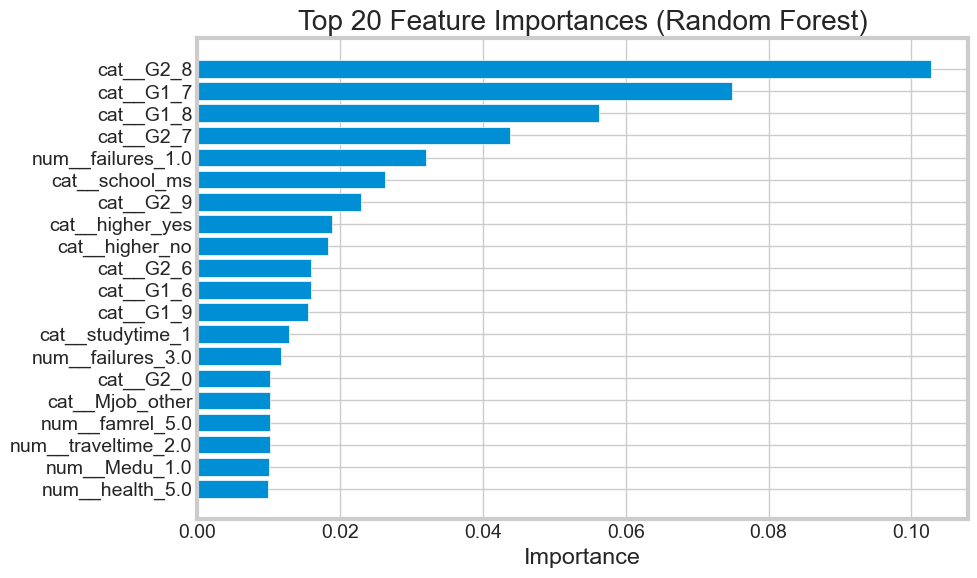

In [161]:
# Feature importance using Random Forest
from sklearn.feature_selection import SelectFromModel


rf_selector = RandomForestClassifier(n_estimators=300, random_state=42)
selector_rf = SelectFromModel(rf_selector, threshold="median")
selector_rf.fit(X_train_pre, y_train)
X_train_selected = selector_rf.transform(X_train_pre)
X_test_selected = selector_rf.transform(X_test_pre)
print(f"Original feature count: {X_train_pre.shape[1]}")
print(f"Selected feature count: {X_train_selected.shape[1]}")

feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

# Visualize feature importance from Random Forest
importances = selector_rf.estimator_.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # Top 20 features
plt.figure(figsize=(10, 6))
plt.title("Top 20 Feature Importances (Random Forest)")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Model accuracy for train set: 0.946
Model accuracy for test set: 0.953

              precision    recall  f1-score   support

           0       0.79      0.79      0.79        14
           1       0.97      0.97      0.97       115

    accuracy                           0.95       129
   macro avg       0.88      0.88      0.88       129
weighted avg       0.95      0.95      0.95       129


Confusion Matrix:
 [[ 11   3]
 [  3 112]]

Accuracy Score:  0.953


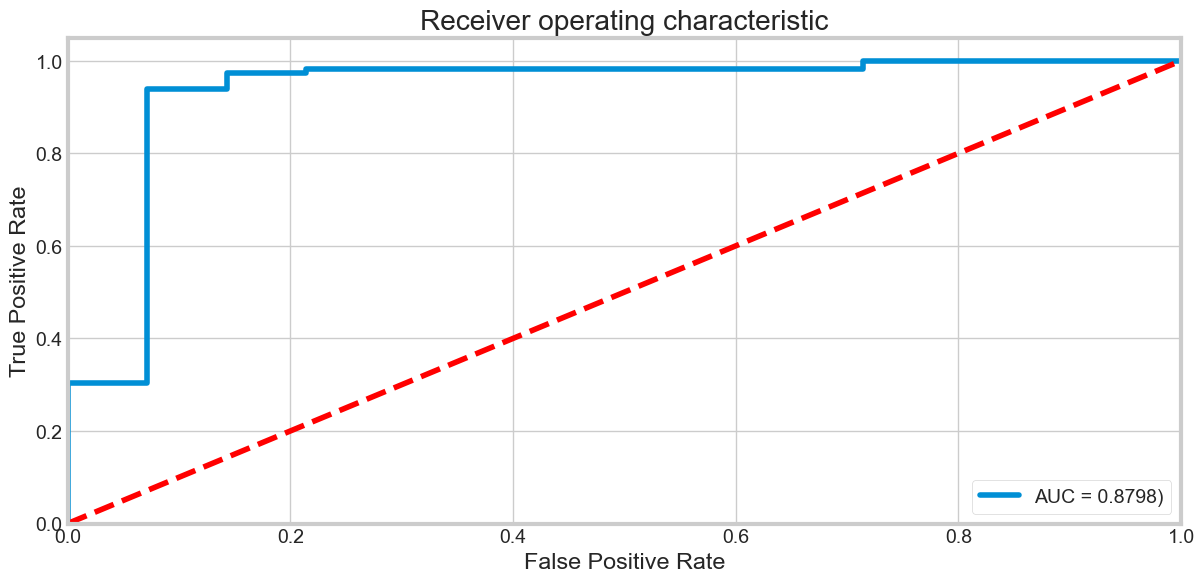

In [164]:
lr = LogisticRegression(random_state=42)
lr_model = train_and_plot(lr, X_train_pre, y_train, X_test_pre, y_test)

In [165]:
plot_model_feature_importances(lr_model)

AttributeError: 'LogisticRegression' object has no attribute 'feature_importances_'

<Figure size 640x480 with 0 Axes>

## Logistic Regression with Hyperparameter Tuning

Optimize logistic regression using GridSearchCV.

Model accuracy for train set: 0.951
Model accuracy for test set: 0.961

              precision    recall  f1-score   support

           0       0.76      0.93      0.84        14
           1       0.99      0.97      0.98       115

    accuracy                           0.96       129
   macro avg       0.88      0.95      0.91       129
weighted avg       0.97      0.96      0.96       129


Confusion Matrix:
 [[ 13   1]
 [  4 111]]

Accuracy Score:  0.961


c:\Users\USER\Downloads\PDS---Test-Prep\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
300 fits failed out of a total of 600.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
300 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\USER\Downloads\PDS---Test-Prep\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\USER\Downloads\PDS---Test-Prep\.venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\USER\Downloads\PDS---Test-Prep\.venv

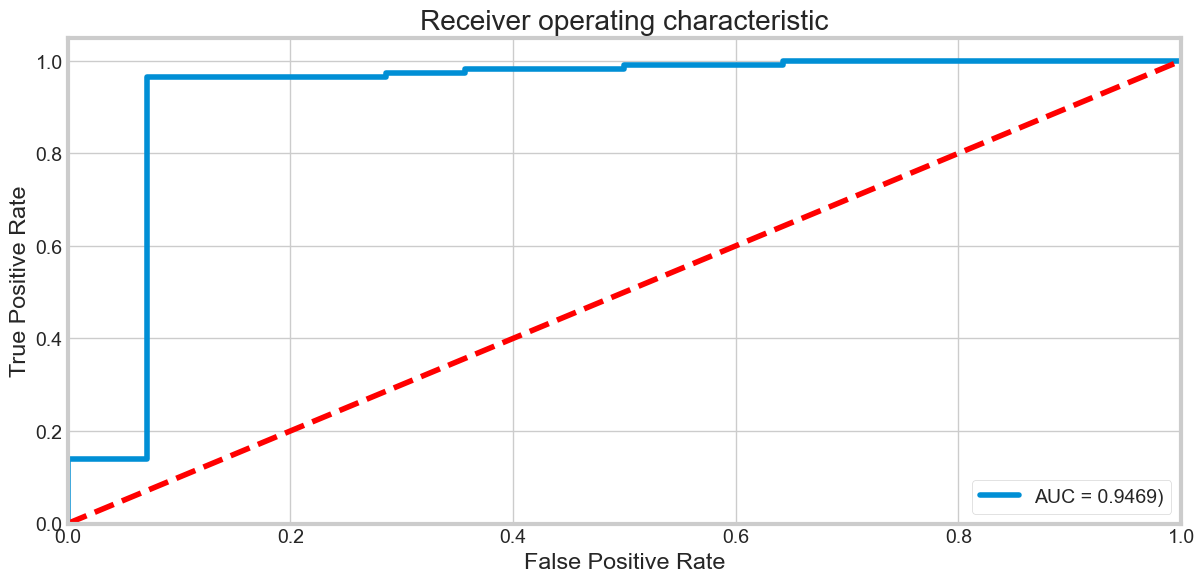

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` 

In [ ]:
LR = LogisticRegression()

params = {
    "penalty": ["l1", "l2"],
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "max_iter": [100, 110, 120, 130, 140],
}

skf = StratifiedKFold(n_splits=10)
LR_hyper = GridSearchCV(LR, param_grid=params, n_jobs=-1, cv=skf)


lr_hyper_model = train_and_plot(LR_hyper, X_train_pre, y_train, X_test_pre, y_test)

# print best parameter and estimator
print("Best Parameters:", lr_hyper_model.best_params_)

# get the best classifier model after hyper-parameter tuning
print("\nBest Classifier:", lr_hyper_model.best_estimator_)

## Base Decision Tree

Train baseline decision tree classifier.

Model accuracy for train set: 1.000
Model accuracy for test set: 0.938

              precision    recall  f1-score   support

           0       0.69      0.79      0.73        14
           1       0.97      0.96      0.96       115

    accuracy                           0.94       129
   macro avg       0.83      0.87      0.85       129
weighted avg       0.94      0.94      0.94       129


Confusion Matrix:
 [[ 11   3]
 [  5 110]]

Accuracy Score:  0.938


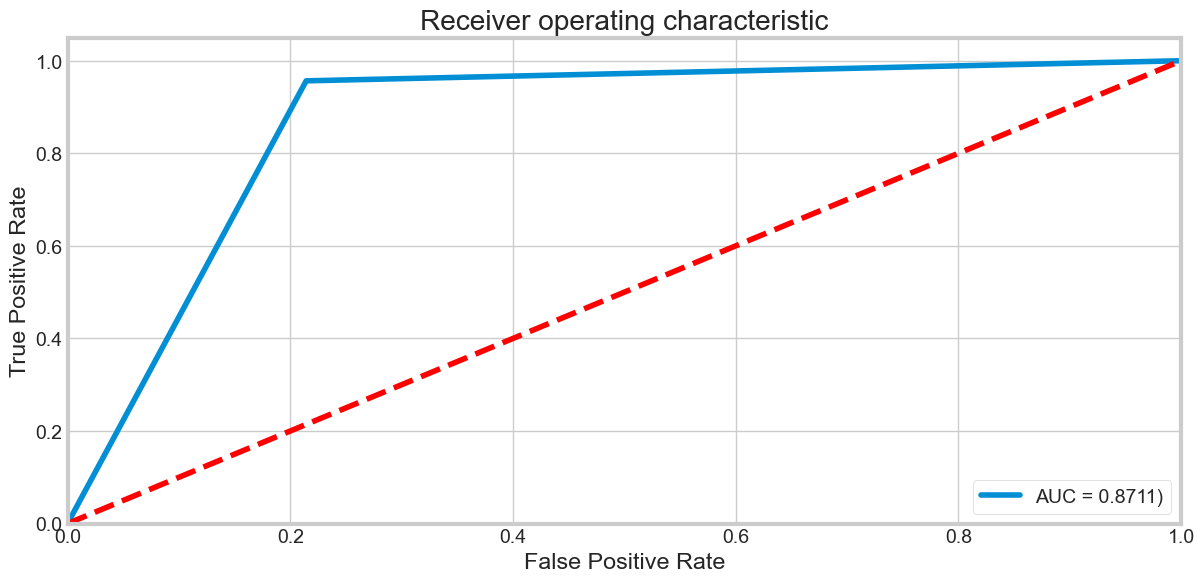

In [146]:
# Base Decision Tree Model
dt = DecisionTreeClassifier(random_state=42)

dt_model = train_and_plot(dt, X_train_pre, y_train, X_test_pre, y_test)

## Decision Tree with Hyperparameter Tuning

Optimize decision tree using GridSearchCV.

Model accuracy for train set: 0.918
Model accuracy for test set: 0.922

              precision    recall  f1-score   support

           0       0.62      0.71      0.67        14
           1       0.96      0.95      0.96       115

    accuracy                           0.92       129
   macro avg       0.79      0.83      0.81       129
weighted avg       0.93      0.92      0.92       129


Confusion Matrix:
 [[ 10   4]
 [  6 109]]

Accuracy Score:  0.922


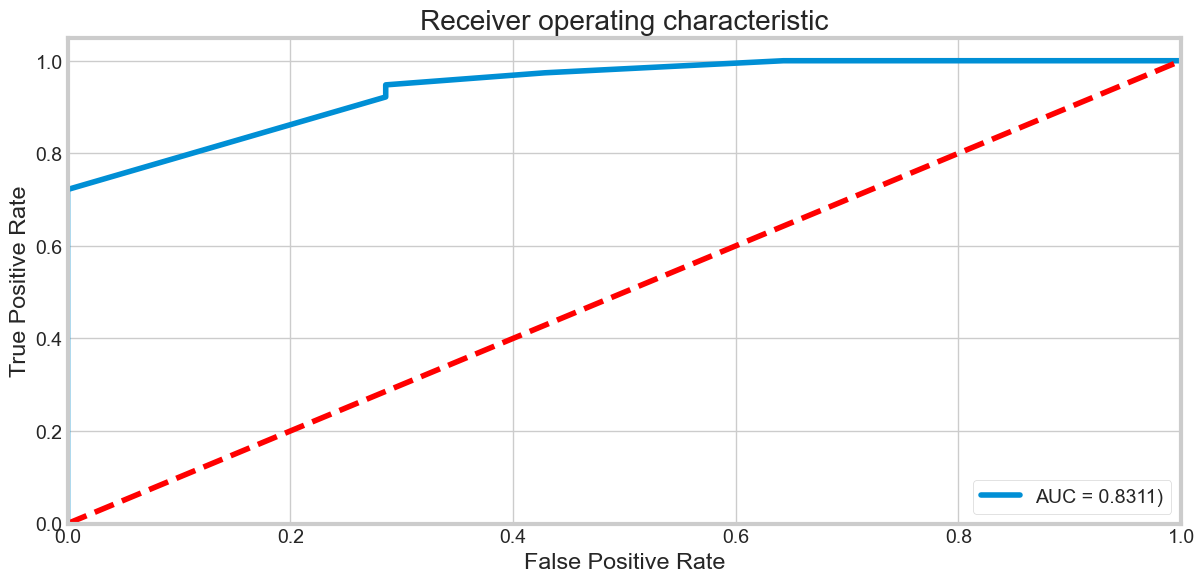

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 2}

Best Classifier: DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=8,
                       random_state=100)


In [157]:
# GridSearchCV to find the optimal tree parameters


tree = DecisionTreeClassifier(random_state=100)

# parameters to build the model on
param_grid = {
    "max_depth": [None, 5, 10, 15, 20, 25, 30],
    "max_features": [None, "sqrt", "log2", 0.5, 0.7, 0.9],
    "min_samples_leaf": [1, 2, 4, 8, 10],
    "min_samples_split": range(2, 10),
    "criterion": ["gini", "entropy"],
}
skf = StratifiedKFold(n_splits=5)

# Instantiating RandomizedSearchCV object
tree_grid = GridSearchCV(tree, param_grid, cv=skf)

tree_model_hyper = train_and_plot(tree_grid, X_train_pre, y_train, X_test_pre, y_test)

# get the best parameter from gird search
print("Best Parameters:", tree_model_hyper.best_params_)

# get the best classifier model after hyper-parameter tuning
print("\nBest Classifier:", tree_model_hyper.best_estimator_)

## Base KNN

Train baseline K-Nearest Neighbors classifier.

Model accuracy for train set: 0.878
Model accuracy for test set: 0.907

              precision    recall  f1-score   support

           0       1.00      0.14      0.25        14
           1       0.91      1.00      0.95       115

    accuracy                           0.91       129
   macro avg       0.95      0.57      0.60       129
weighted avg       0.92      0.91      0.87       129


Confusion Matrix:
 [[  2  12]
 [  0 115]]

Accuracy Score:  0.907


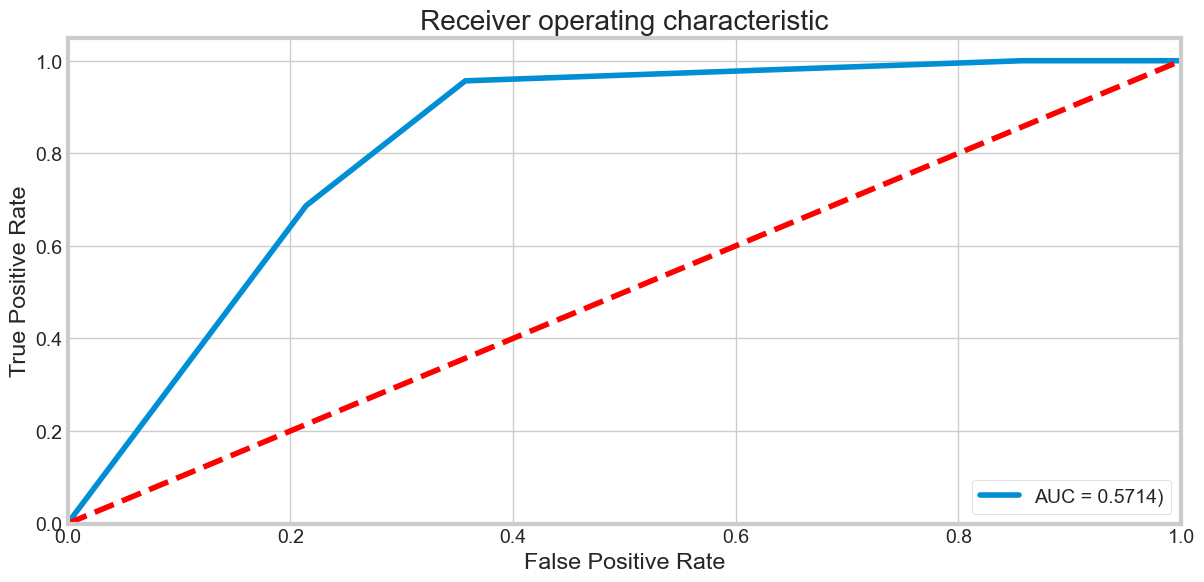

In [147]:
# KNN b

knn = KNeighborsClassifier()
knn_model = train_and_plot(knn, X_train_pre, y_train, X_test_pre, y_test)

Model accuracy for train set: 0.878
Model accuracy for test set: 0.907

              precision    recall  f1-score   support

           0       1.00      0.14      0.25        14
           1       0.91      1.00      0.95       115

    accuracy                           0.91       129
   macro avg       0.95      0.57      0.60       129
weighted avg       0.92      0.91      0.87       129


Confusion Matrix:
 [[  2  12]
 [  0 115]]

Accuracy Score:  0.907


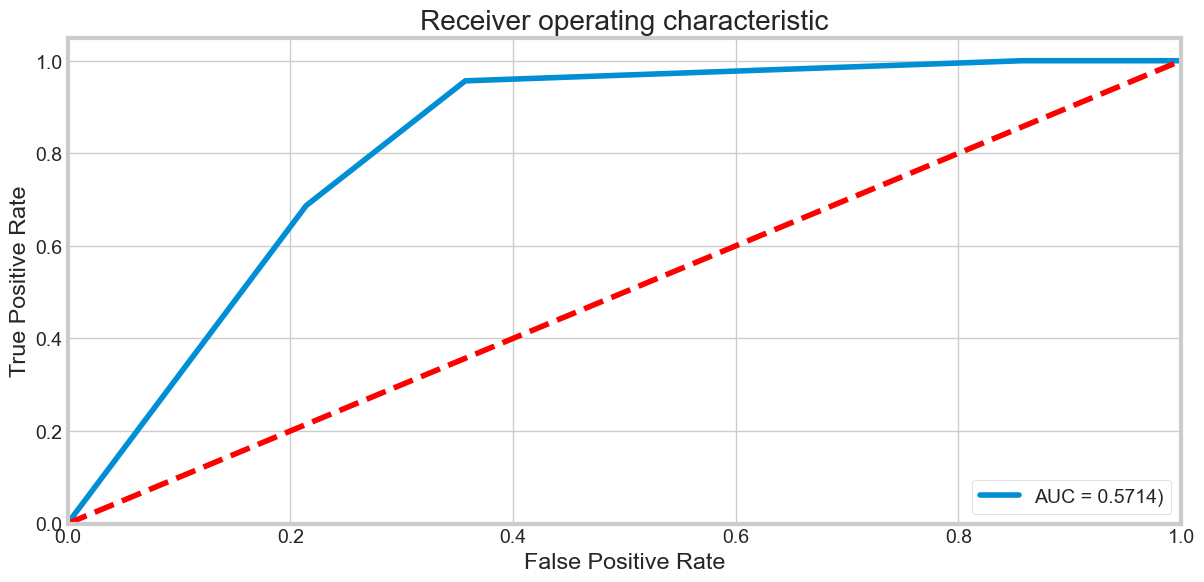

In [148]:
# KNN with hyperparameter tuning
KNN = KNeighborsClassifier()

params = {
    "n_neighbors": list(range(1, 40, 2)),
    "weights": ["uniform", "distance"],
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
}

skf = StratifiedKFold(n_splits=10)
KNN_hyper = GridSearchCV(KNN, param_grid=params, n_jobs=-1, cv=skf)

knn_model_hyper = train_and_plot(KNN_hyper, X_train_pre, y_train, X_test_pre, y_test)

## Base Random Forest

Train baseline random forest classifier.

Model accuracy for train set: 1.000
Model accuracy for test set: 0.953

              precision    recall  f1-score   support

           0       0.90      0.64      0.75        14
           1       0.96      0.99      0.97       115

    accuracy                           0.95       129
   macro avg       0.93      0.82      0.86       129
weighted avg       0.95      0.95      0.95       129


Confusion Matrix:
 [[  9   5]
 [  1 114]]

Accuracy Score:  0.953


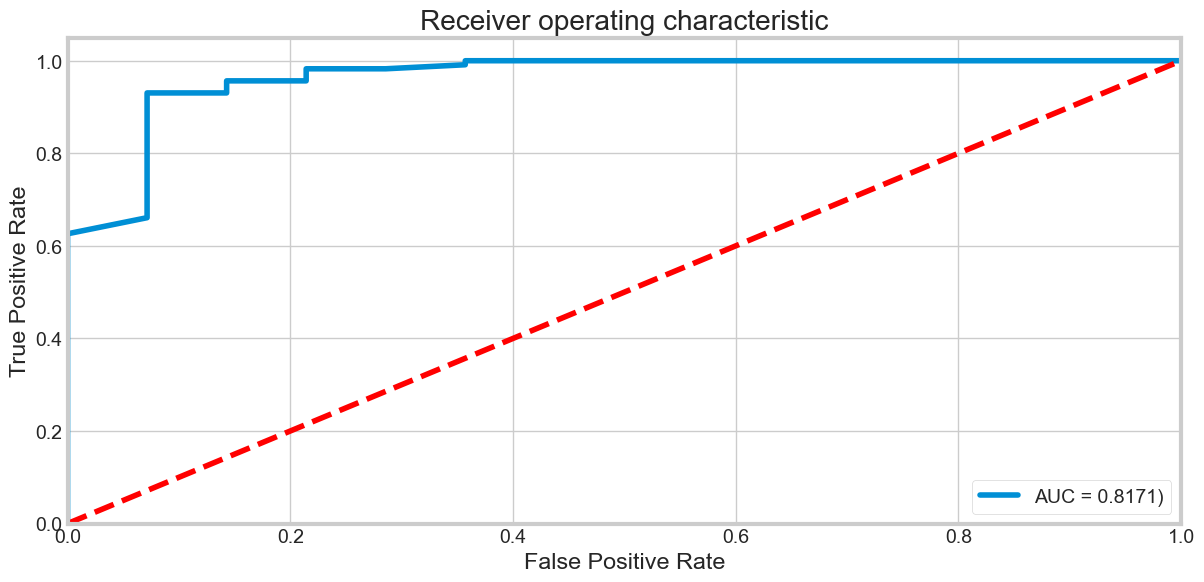

In [149]:
rf = RandomForestClassifier(random_state=42)

rf_model = train_and_plot(rf, X_train_pre, y_train, X_test_pre, y_test)

# 7. Regression Models

Train and evaluate regression models.

In [150]:
# Define features and target
X = df.drop(TARGET, axis=1)
y = df[TARGET]

# Basic split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (515, 24)
Test shape: (129, 24)


In [151]:
pipeline.fit(X_train, y_train)
X_train_pre = pipeline.transform(X_train)
X_test_pre = pipeline.transform(X_test)

c:\Users\USER\Downloads\PDS---Test-Prep\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [8, 13] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [ ]:
def train_and_plot_regression(model, X_train, y_train, X_test, y_test):
    """Train regression model and display relevant metrics"""
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # R² Score
    print(f"R² Score (Train): {r2_score(y_train, y_train_pred):.3f}")
    print(f"R² Score (Test):  {r2_score(y_test, y_test_pred):.3f}")

    # MSE & RMSE
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    print(f"\nMSE:  {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")

    # MAE
    mae = mean_absolute_error(y_test, y_test_pred)
    print(f"MAE:  {mae:.3f}")

    # Residual Plot
    residuals = y_test - y_test_pred
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Predicted vs Actual
    axes[0].scatter(y_test, y_test_pred, alpha=0.5)
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    axes[0].set_xlabel("Actual")
    axes[0].set_ylabel("Predicted")
    axes[0].set_title("Predicted vs Actual")
    axes[0].legend(["Ideal Prediction", "Predicted Values"])

    # Residuals distribution
    axes[1].hist(residuals, bins=30, edgecolor="black")
    axes[1].set_xlabel("Residuals")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title("Residuals Distribution")

    plt.tight_layout()
    plt.show()

    return model

## Base Linear Regression

Train baseline linear regression model.

R² Score (Train): 0.876
R² Score (Test):  0.824

MSE:  2.092
RMSE: 1.446
MAE:  0.919


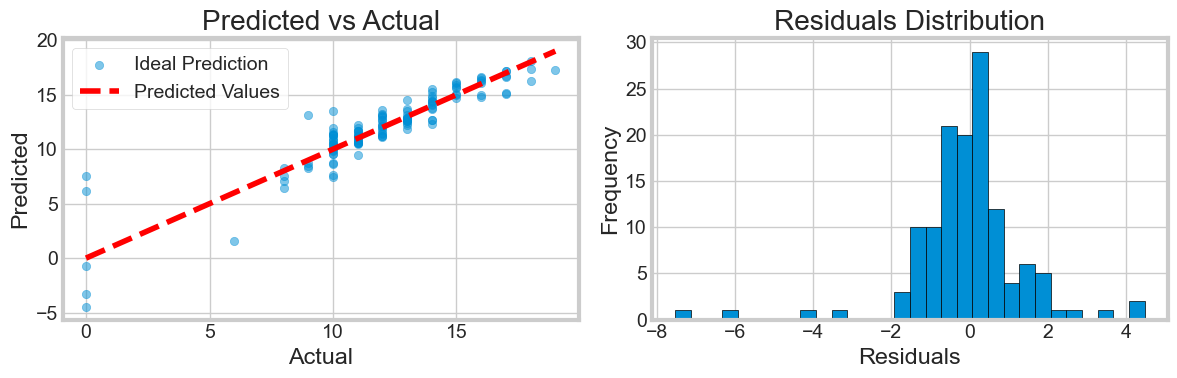

In [156]:
lr = LinearRegression()

lr_model = train_and_plot_regression(lr, X_train_pre, y_train, X_test_pre, y_test)

## Linear Regression with Hyperparameter Tuning

Optimize linear regression using GridSearchCV.

In [ ]:
# Linear Regression with hyperparameter tuning
LR = LinearRegression()

params = {

## Base Lasso Regression

Train baseline Lasso regression model.

R² Score (Train): 0.000
R² Score (Test):  -0.000

MSE:  11.868
RMSE: 3.445
MAE:  2.425


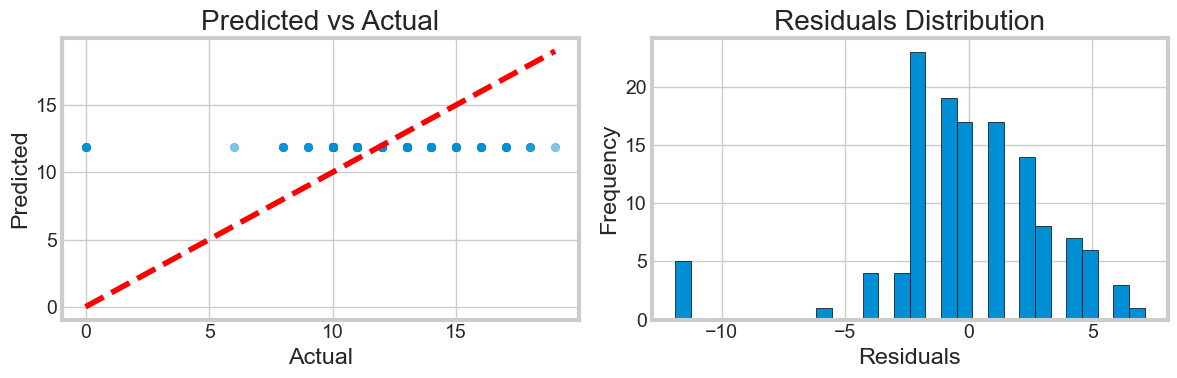

In [154]:
lasso = Lasso()
lasso_model = train_and_plot_regression(lasso, X_train_pre, y_train, X_test_pre, y_test)

R² Score (Train): 0.865
R² Score (Test):  0.845

MSE:  1.837
RMSE: 1.356
MAE:  0.868


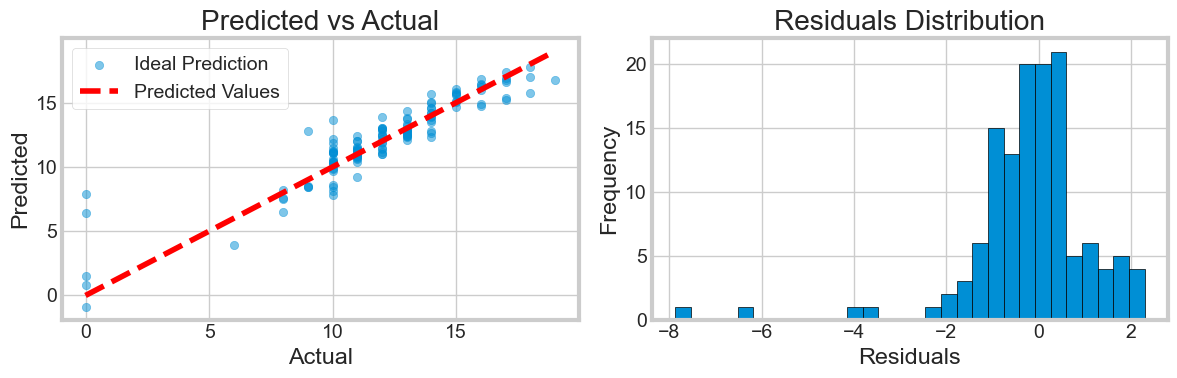

In [157]:
ridge = Ridge()
ridge_model = train_and_plot_regression(ridge, X_train_pre, y_train, X_test_pre, y_test)

In [173]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

lasso = Lasso(alpha=0.01)
selector = SelectFromModel(lasso)

selector.fit(X_train_pre, y_train)

# Get feature names from the pipeline
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
selected_features = feature_names[selector.get_support()]

print(f"Selected {len(selected_features)} features:")
print(selected_features)

Selected 52 features:
['cat__school_ms' 'cat__sex_m' 'cat__age_15' 'cat__age_17'
 'cat__address_r' 'cat__Mjob_at_home' 'cat__Mjob_other'
 'cat__Mjob_services' 'cat__Fjob_at_home' 'cat__Fjob_services'
 'cat__reason_home' 'cat__reason_other' 'cat__reason_reputation'
 'cat__studytime_1' 'cat__studytime_2' 'cat__activities_no'
 'cat__higher_no' 'cat__internet_no' 'cat__romantic_yes' 'cat__G1_10'
 'cat__G1_11' 'cat__G1_12' 'cat__G1_14' 'cat__G1_15' 'cat__G1_16'
 'cat__G1_17' 'cat__G1_18' 'cat__G1_5' 'cat__G1_7' 'cat__G1_8' 'cat__G1_9'
 'cat__G2_0' 'cat__G2_10' 'cat__G2_11' 'cat__G2_13' 'cat__G2_14'
 'cat__G2_15' 'cat__G2_16' 'cat__G2_17' 'cat__G2_18' 'cat__G2_19'
 'cat__G2_5' 'cat__G2_6' 'cat__G2_7' 'cat__G2_8' 'cat__G2_9'
 'num__traveltime' 'num__failures' 'num__freetime' 'num__goout'
 'num__health' 'num__absences']


In [ ]:


rf = RandomForestRegressor(n_estimators=300, random_state=42)
selector = SelectFromModel(rf, threshold="median")

selector.fit(X_train_pre, y_train)
# Get feature names from the pipeline
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
selected_features = feature_names[selector.get_support()]

print(f"Selected {len(selected_features)} features:")
print(selected_features)

Selected 48 features:
['cat__age_17' 'cat__age_18' 'cat__Mjob_other' 'cat__Mjob_teacher'
 'cat__Fjob_services' 'cat__Fjob_teacher' 'cat__reason_home'
 'cat__reason_other' 'cat__studytime_2' 'cat__romantic_no'
 'cat__romantic_yes' 'cat__G1_10' 'cat__G1_11' 'cat__G1_13' 'cat__G1_14'
 'cat__G1_15' 'cat__G1_16' 'cat__G1_17' 'cat__G1_18' 'cat__G1_5'
 'cat__G1_7' 'cat__G1_8' 'cat__G1_9' 'cat__G2_0' 'cat__G2_10' 'cat__G2_11'
 'cat__G2_12' 'cat__G2_13' 'cat__G2_14' 'cat__G2_15' 'cat__G2_16'
 'cat__G2_17' 'cat__G2_18' 'cat__G2_19' 'cat__G2_5' 'cat__G2_6'
 'cat__G2_7' 'cat__G2_8' 'cat__G2_9' 'num__Medu' 'num__Fedu'
 'num__traveltime' 'num__failures' 'num__famrel' 'num__freetime'
 'num__goout' 'num__health' 'num__absences']


In [177]:
# Transform data to use only selected features
X_train_selected = selector.transform(X_train_pre)
X_test_selected = selector.transform(X_test_pre)

print(f"Original features: {X_train_pre.shape[1]}")
print(f"Selected features: {X_train_selected.shape[1]}")

Original features: 95
Selected features: 48


R² Score (Train): 0.867
R² Score (Test):  0.844

MSE:  1.856
RMSE: 1.362
MAE:  0.871


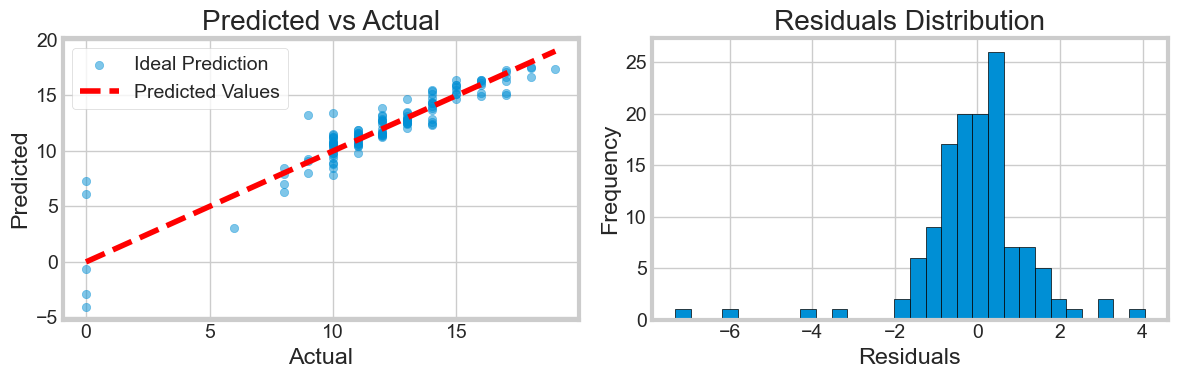

In [178]:
# Linear Regression with selected features only
lr_selected = LinearRegression()
lr_selected_model = train_and_plot_regression(
    lr_selected, X_train_selected, y_train, X_test_selected, y_test
)